# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
from matplotlib.ticker import FuncFormatter

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


**1.2:**  How will your solution be used?


**1.3:**  How should success (or failure) be measured?


## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fips,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,3100.0,3100.0,NaN,NaN,NaN,NaN,6059.0,NaN,3.0,2.0,633.0,NaN,NaN,33634931.0,-117869207.0,4506.0,NaN,NaN,NaN,NaN,NaN,122,261.0,NaN,6.059063e+07,53571.0,1286.0,NaN,96978.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,1465.0,1465.0,1465.0,NaN,NaN,1465.0,NaN,6111.0,1.0,1.0,1.0,0.0,NaN,NaN,34449266.0,-119281531.0,12647.0,NaN,NaN,NaN,NaN,NaN,1110,261.0,NaN,6.111001e+07,13091.0,2061.0,NaN,97099.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,NaN,1243.0,1243.0,NaN,NaN,NaN,NaN,6059.0,NaN,2.0,2.0,440.0,NaN,NaN,33886168.0,-117823170.0,8432.0,1.0,NaN,NaN,NaN,1.0,122,261.0,NaN,6.059022e+07,21412.0,1286.0,NaN,97078.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,NaN,2376.0,2376.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34245180.0,-118240722.0,13038.0,1.0,NaN,NaN,NaN,1.0,0101,261.0,LCR110000*,6.037300e+07,396551.0,3101.0,NaN,96330.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,NaN,1312.0,1312.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34185120.0,-118414640.0,278581.0,1.0,NaN,NaN,NaN,1.0,010C,266.0,LAR3,6.037124e+07,12447.0,3101.0,268548.0,96451.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [5]:
df.nunique().sort_values(ascending=False).to_frame(name='Unique Values')

,Unique Values
parcelid,77414
latitude,64038
longitude,62461
taxvaluedollarcnt,50949
rawcensustractandblock,39188
censustractandblock,39006
lotsizesquarefeet,18848
calculatedfinishedsquarefeet,4972
finishedsquarefeet12,4868
propertyzoningdesc,1907


In [6]:
# Features 27-54
features_2nd_half = df.columns.tolist()[27:55]
features_2nd_half

['poolcnt',
 'poolsizesum',
 'pooltypeid10',
 'pooltypeid2',
 'pooltypeid7',
 'propertycountylandusecode',
 'propertylandusetypeid',
 'propertyzoningdesc',
 'rawcensustractandblock',
 'regionidcity',
 'regionidcounty',
 'regionidneighborhood',
 'regionidzip',
 'roomcnt',
 'storytypeid',
 'threequarterbathnbr',
 'typeconstructiontypeid',
 'unitcnt',
 'yardbuildingsqft17',
 'yardbuildingsqft26',
 'yearbuilt',
 'numberofstories',
 'fireplaceflag',
 'assessmentyear',
 'taxdelinquencyflag',
 'taxdelinquencyyear',
 'censustractandblock',
 'taxvaluedollarcnt']

In [7]:
df[features_2nd_half].nunique().sort_values(ascending=False).to_frame(name='Unique Values')

,Unique Values
taxvaluedollarcnt,50949
rawcensustractandblock,39188
censustractandblock,39006
propertyzoningdesc,1907
yardbuildingsqft17,540
regionidneighborhood,480
regionidzip,389
poolsizesum,262
regionidcity,175
yearbuilt,136


In [8]:
df[features_2nd_half].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   poolcnt                    16174 non-null  float64
 1   poolsizesum                869 non-null    float64
 2   pooltypeid10               465 non-null    float64
 3   pooltypeid2                1074 non-null   float64
 4   pooltypeid7                15079 non-null  float64
 5   propertycountylandusecode  77579 non-null  object 
 6   propertylandusetypeid      77579 non-null  float64
 7   propertyzoningdesc         50476 non-null  object 
 8   rawcensustractandblock     77579 non-null  float64
 9   regionidcity               76107 non-null  float64
 10  regionidcounty             77579 non-null  float64
 11  regionidneighborhood       30974 non-null  float64
 12  regionidzip                77529 non-null  float64
 13  roomcnt                    77579 non-null  flo

All columns are numerical (float64) except for `propertycountylandusecode`, `propertyzoningdesc`, `fireplaceflag`, `taxdelinquencyflag` (objects - strings)      

In [9]:
df['propertycountylandusecode'].unique()

array(['122', '1110', '0101', '010C', '1129', '0100', '38', '34', '1111',
       '012C', '010V', '1', '0103', '010D', '0200', '010E', '0300', '96',
       '0104', '0400', '01DC', '01HC', nan, '1321', '1410', '0108',
       '1128', '010G', '1720', '010H', '1210', '0102', '010F', '010M',
       '1117', '0201', '0700', '1722', '73', '0109', '0301', '01HE',
       '135', '0204', '0401', '070D', '0113', '0133', '0131', '1432',
       '040G', '1112', '1222', '1310', '1120', '0111', '1116', '1421',
       '0110', '0105', '012E', '0141', '1333', '0115', '040V', '010L',
       '040B', '012D', '0114', '0203', '030G', '0130', '105', '020G',
       '020M', '020E'], dtype=object)

In [10]:
df['propertyzoningdesc'].unique()

array([nan, 'LCR110000*', 'LAR3', ..., 'HAR4-R2*', 'LCR1VV', 'BFA15000*'],
      shape=(1908,), dtype=object)

In [11]:
# It would make sense to set nan values for 'fireplaceflag' as False (or encode 0 for False and 1 for True)
df['fireplaceflag'].unique()

array([nan, True], dtype=object)

In [12]:
# It would make sense to set nan values for 'taxdelinquencyflag' as 'N' (or encode 0 for nan and 1 for 'Y')
df['taxdelinquencyflag'].unique()

array([nan, 'Y'], dtype=object)

In [13]:
print(f'Total Number of Samples: {len(df):,}')

Total Number of Samples: 77,613


In [14]:
# Null %'s

null_counts = df[features_2nd_half].isnull().sum().to_frame(name='Null Counts')
null_counts['Non-Null Counts'] = df[features_2nd_half].notnull().sum()
null_counts['Null Percentage'] = (null_counts['Null Counts'] / len(df[features_2nd_half])) * 100

null_counts.sort_values(by='Null Percentage', ascending=False)

,Null Counts,Non-Null Counts,Null Percentage
storytypeid,77563,50,99.935578
yardbuildingsqft26,77543,70,99.909809
fireplaceflag,77441,172,99.778388
typeconstructiontypeid,77390,223,99.712677
pooltypeid10,77148,465,99.400874
poolsizesum,76744,869,98.880342
pooltypeid2,76539,1074,98.616211
yardbuildingsqft17,75220,2393,96.916754
taxdelinquencyflag,74713,2900,96.263513
taxdelinquencyyear,74713,2900,96.263513


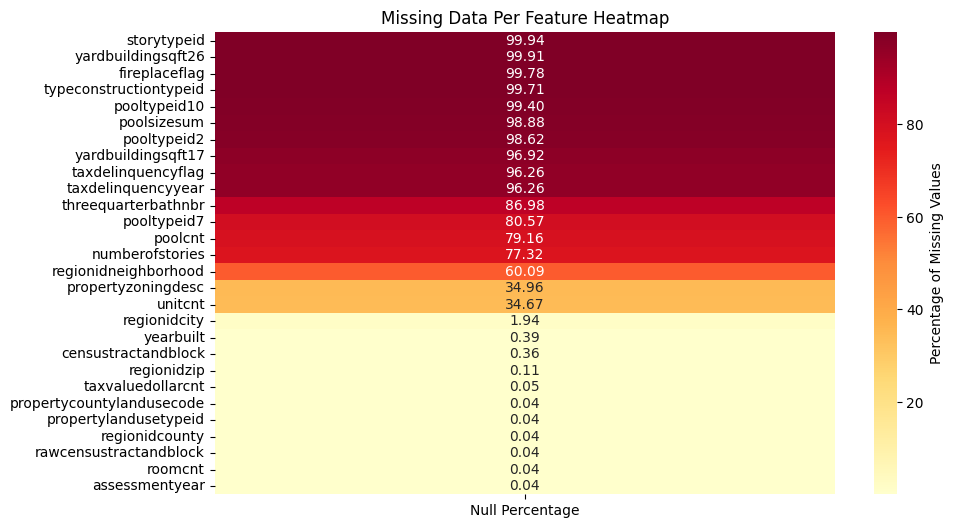

In [15]:
null_pct = null_counts['Null Percentage'].to_frame(name='Null Percentage').sort_values(by='Null Percentage', ascending=False)

plt.figure(figsize=(10, 6))
sns.heatmap(null_pct, annot=True, fmt=".2f", cmap='YlOrRd', cbar_kws={'label': 'Percentage of Missing Values'})
plt.title('Missing Data Per Feature Heatmap')
plt.show()

Before analyzing each feature, likely the features in the mid to high 90% are useless or weak features in predicting the overall `taxvaluedollarcnt`. However, there are some flag features that could be encoded later on so that the nan are the False values or 0. These features still might be useful in the model building process later, but likely aren't strong features to build a model from as most are the missing or False value. But as the features stand currently, the features with high 90 percentage missing values are likely not useful in predicting the overall tax assessment of houses.

#### 90% or more missing values - Unique Values

In [16]:
df['storytypeid'].unique()

array([nan,  7.])

In [17]:
df['yardbuildingsqft26'].unique()

array([ nan, 196., 300.,  56.,  88., 120., 160.,  45., 752., 169., 448.,
        21., 200.,  33., 113.,  41., 314.,  30.,  12., 414.,  66., 648.,
       174., 218.,  60., 336., 108., 144., 216., 360.,  72., 368.,  37.,
       105.,  28., 461.,  48., 240., 284.,  39., 133., 486., 250.,  91.,
       491., 575.,  16., 140.,  71., 204., 195., 292., 231., 320., 384.,
       180.,  49., 868., 462., 576.])

In [18]:
df['fireplaceflag'].unique()

array([nan, True], dtype=object)

In [19]:
df['typeconstructiontypeid'].unique()

array([nan,  6., 13., 10.,  4.])

In [20]:
df['pooltypeid10'].unique()

array([nan,  1.])

In [21]:
df['poolsizesum'].unique()

array([  nan,  400.,  578.,  325.,  480.,  360.,  500.,  570.,  794.,
        560.,  646.,  375.,  600.,  800.,  450.,  760.,  832.,  372.,
        405.,  820.,  525.,  324.,  550.,  288.,  576.,  640.,  747.,
        460.,  129.,  740.,  562.,  655.,  504.,  544.,  350.,  467.,
        557.,  448.,  230.,  554.,  663.,  615.,  420.,  602.,  675.,
        512.,   24.,  200.,  451., 1500.,  764.,  700.,  540.,  290.,
        595.,  459.,  430.,  510.,  495.,  648.,  592.,  702.,  390.,
        476.,  172.,  240.,  799.,  684.,  710.,  387.,  340.,  440.,
        264.,   65.,  660., 1000.,  458.,  256.,  590.,  720.,  365.,
        300.,  280.,  900.,  680.,  624.,  304.,  580.,  594.,  587.,
        598.,  456.,  589.,  750.,  631.,  403.,  402.,  840.,  520.,
        627.,  673.,  353.,  306.,  380.,  543.,  424.,  770.,  552.,
        642.,  362.,  608.,  472.,  408.,  885.,  650.,  416.,  312.,
        528.,  320.,  432.,  112.,  364.,  435.,  468.,  427.,  485.,
        345.,  378.,

In [22]:
df['pooltypeid2'].unique()

array([nan,  1.])

In [23]:
df['yardbuildingsqft17'].unique()

array([  nan,  306.,  160.,  318.,  252.,  196.,  245.,  260.,  282.,
        345.,  537., 2332.,  370., 2206.,  300.,  360.,  244.,  144.,
        320.,  200.,  420.,  600.,  432.,  150.,  195.,  566.,  290.,
         80.,  308.,  270.,   86.,  312.,  108.,  780.,  440.,   98.,
        100.,  175.,  628.,  231.,  264.,  120.,  236.,  250.,  240.,
        288.,  256.,  280.,  146.,  481.,  392.,  221.,   90.,  575.,
        378.,  140.,  180.,   83.,   79.,  352.,  568.,  567.,  113.,
        361.,  112.,  451.,  208.,  125.,  220.,  452.,  276.,  630.,
        450.,   57.,  128.,   44.,   72.,  400.,  484.,  198.,  375.,
        230.,  192.,  134.,  104.,  110.,   42.,  396.,   81.,  124.,
        416.,  560.,   28.,  286.,  700.,  825.,  336.,  126., 1324.,
        216.,  350.,  888.,   91.,  512.,  496.,  317.,  466.,   55.,
        942.,  297.,  170.,  418.,   45.,  147.,  476.,   41.,  279.,
        130.,  550.,  598.,  648.,  792.,  119.,   94.,  330.,   78.,
        172.,   70.,

In [24]:
df['taxdelinquencyflag'].unique()

array([nan, 'Y'], dtype=object)

In [25]:
df['taxdelinquencyyear'].unique()

array([nan, 15., 14.,  9., 11., 10., 13., 12.,  3.,  7.,  6.,  8., 99.,
        4.])

In [26]:
df[features_2nd_half].describe()

,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertylandusetypeid,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,assessmentyear,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
count,16174.0,869.000000,465.0,1074.0,15079.0,77579.000000,7.757900e+04,76107.000000,77579.000000,30974.000000,77529.000000,77579.000000,50.0,10106.000000,223.000000,50703.000000,2393.000000,70.000000,77309.000000,17599.000000,77579.0,2900.000000,7.733200e+04,7.757800e+04
mean,1.0,517.930955,1.0,1.0,1.0,261.824476,6.049124e+07,33683.055107,2534.514933,187725.110544,96586.692812,1.476276,7.0,1.009598,6.040359,1.110309,305.460928,216.385714,1968.611507,1.434286,2016.0,14.088276,6.049667e+13,4.901506e+05
std,0.0,156.569664,0.0,0.0,0.0,5.141596,2.058962e+05,47211.780350,801.447913,165045.086058,3793.552065,2.823686,0.0,0.118572,0.556035,1.169967,238.735241,190.177514,23.793171,0.544515,0.0,2.181281,1.533339e+12,6.537979e+05
min,1.0,24.000000,1.0,1.0,1.0,31.000000,6.037101e+07,3491.000000,1286.000000,6952.000000,95982.000000,0.000000,7.0,1.000000,4.000000,1.000000,11.000000,12.000000,1824.000000,1.000000,2016.0,3.000000,6.037101e+13,1.000000e+03
25%,1.0,424.000000,1.0,1.0,1.0,261.000000,6.037311e+07,12447.000000,1286.000000,46736.000000,96193.000000,0.000000,7.0,1.000000,6.000000,1.000000,170.000000,61.500000,1953.000000,1.000000,2016.0,14.000000,6.037311e+13,2.068985e+05
50%,1.0,500.000000,1.0,1.0,1.0,261.000000,6.037603e+07,25218.000000,3101.000000,118849.000000,96389.000000,0.000000,7.0,1.000000,6.000000,1.000000,250.000000,164.500000,1970.000000,1.000000,2016.0,15.000000,6.037603e+13,3.588785e+05
75%,1.0,600.000000,1.0,1.0,1.0,266.000000,6.059042e+07,45457.000000,3101.000000,274765.000000,96987.000000,0.000000,7.0,1.000000,6.000000,1.000000,364.000000,310.500000,1987.000000,2.000000,2016.0,15.000000,6.059042e+13,5.690000e+05
max,1.0,1500.000000,1.0,1.0,1.0,275.000000,6.111009e+07,396556.000000,3101.000000,764167.000000,399675.000000,15.000000,7.0,7.000000,13.000000,237.000000,3191.000000,868.000000,2016.000000,6.000000,2016.0,99.000000,4.830301e+14,4.906124e+07


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

  - 2nd half features: `propertycountylandusecode`, `propertyzoningdesc`, `fireplaceflag`, `taxdelinquencyflag`

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

**1st Half Features (0-26)**

**2nd Half Features (27-54)**

  - `censustractandblock` and `rawcensustractandblock` are not *useless*, but they are likely redundant as there are already features for locational information for the houses (e.g., `regionidneighborhood`, `regionidcity`, `regionidzip`, `regionidcounty`)
  
  - `poolcnt` is useless because all the houses that have pools have just one. The min and max are 1.0. The same with `pooltypeid10`, `pooltypeid2`, and `pooltypeid7`. They only have nan or 1.0. It would be better to just analyze the size of the pool. Or, you could replace the pool features (besides the size) with a flag feature to indicate if they have a pool or not. 


**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 


**1st Half Features (0-26)**

**2nd Half Features (27-54)**

  - `fireplaceflag`: 99.78% are null. The unique values are nan or True. This means the vast majority of houses do not have a fireplace. This will not be a great predictor in the overall tax assessment value of the houses.

  - `storytypeid`: 99.94% are null. The unique values are nan or 7. This will not be a usefull feature as there are very few houses with actual values outside of being nan. 

  - `typeconstructiontypeid`: 99.71% are null. Again, a vast majority of house samples do not have a value other than nan so it is not going to be a useful feature most likely since the distribution is heavily skewed to nan.

From the heatmap below, I'd say that a cutoff at first glance for the **useless** features for predicting the tax assessment value of houses should be >90%. 
  - This includes `storytypeid`, `yardbuildingsqft26`, `fireplaceflag`, `typeconstructiontypeid`, `pooltypeid10`, `poolsizesum`, `pooltypeid2`, `yardbuildingsqft17`, `taxdelinquencyflag`, `taxdelinquencyyear`. These feature range from 50-2900 non-null values. 

The cutoff for keeping the features, at least at first glance would be `threequarterbathnbr` because there are over 10,000 houses with non-null values. This is about a seventh of the dataset which is still significant. Plus, just from the name of the feature it might be useful since it has to do with bathrooms and bedrooms.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

**1st Half Features (0-26)**

**2nd Half Features (27-54)**
  - `pooltypeid7`, `pooltypeid2`, `pooltypeid10`, `storytypeid`, `assessmentyear` are likely useless because they only have one unique value.
  - `poolcnt` is not completely useless as it may affect the tax value of a house, but it may be better to transform this feature into a False/True (or encoded as 0/1) feature like 'hasPool' versus the count of the pools since there is only one unique value.
  - `fireplaceflag` and `taxdelinquencyflag` may not be completely useless since they indicates whether or not a house has a fireplace or the house is tax deliquent, but the way the features are set up is poor. It would be better if each were converted so they have two unique values: False/True (or encoded as 0/1). As noted above, these flags are mostly null features, so they might not be as useful as other features.


### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

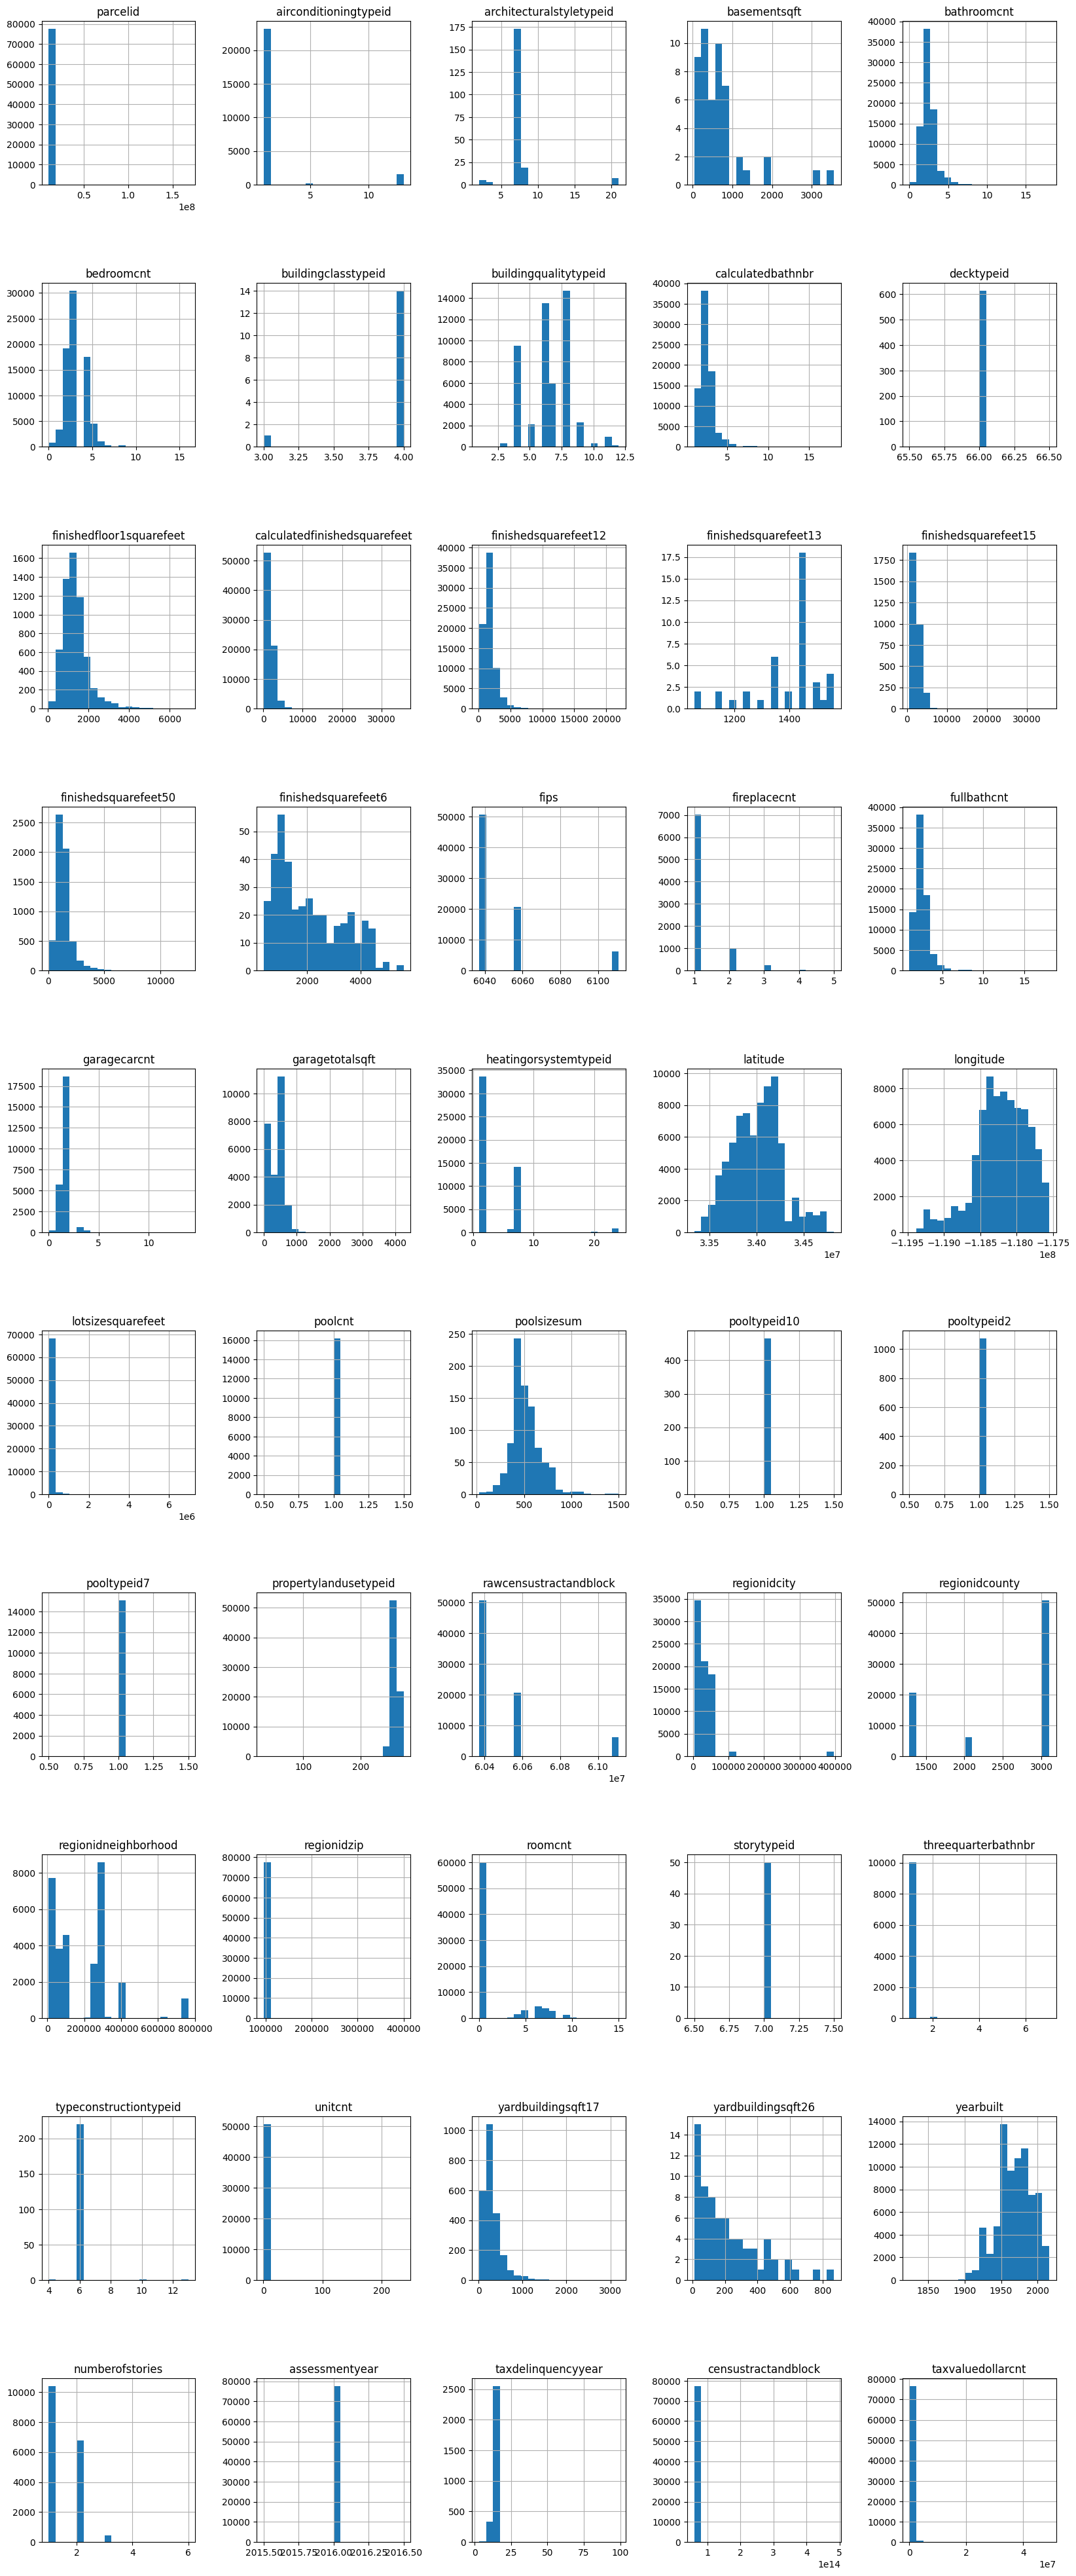

In [27]:
df.hist(figsize=(20,50), layout=(-1,5), bins=20)
plt.subplots_adjust(hspace=0.6, wspace=0.4)
plt.show()

In [28]:
df['roomcnt'].max()

np.float64(15.0)

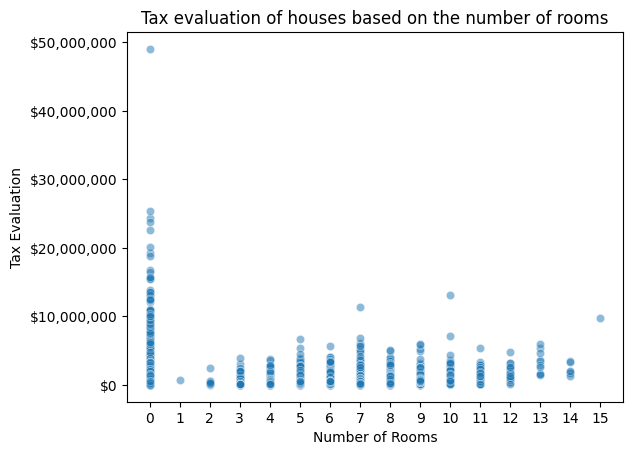

In [29]:
formatter = FuncFormatter(dollar_format)

ax = sns.scatterplot(df, x='roomcnt', y='taxvaluedollarcnt', alpha=0.5)

plt.xticks(np.arange(0, 16, 1))
ax.yaxis.set_major_formatter(formatter)

plt.xlabel('Number of Rooms')
plt.ylabel('Tax Evaluation')
plt.title('Tax evaluation of houses based on the number of rooms')

plt.show()

Interestingly, there is a significant amount of houses with 0 rooms which doesn't make sense. Also, a major outlier in this visualization is the house nearly worth $50M while having 0 rooms.

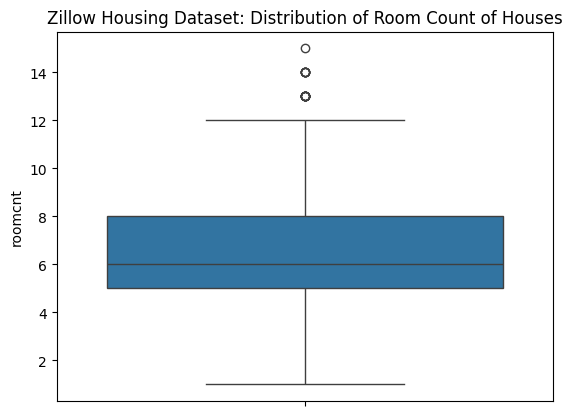

In [30]:
sns.boxplot(df['roomcnt'][df['roomcnt'] > 0])
plt.title('Zillow Housing Dataset: Distribution of Room Count of Houses')
plt.show()

A box plot of the *clean* part (ignoring houses with 0 rooms for now) of the `roomcnt` feature to show the distribution. The `roomcnt` feature is right skewed because the median is closer to the bottom of the box. The median number of rooms in the dataset is 6. Q1 is 5, which means 25% of the houses have 5 rooms or fewer. Q3 is 8, which means 75% of the houses have 8 rooms or fewer. The whiskers show the normal range from 1 to 12 rooms. There are outlier houses above the range which have 13-15 rooms. This feature was chosen because it is a crucial factor people consider when purchasing homes.

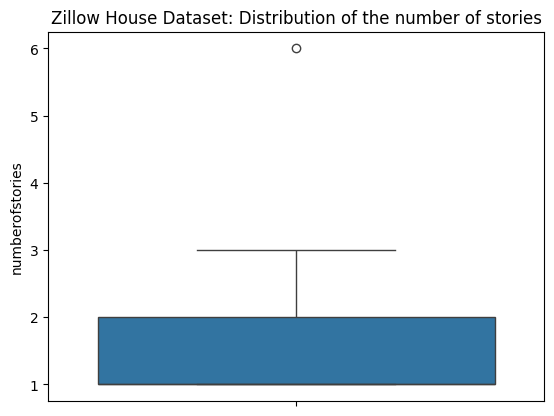

In [31]:
sns.boxplot(df['numberofstories'])
plt.title('Zillow House Dataset: Distribution of the number of stories')
plt.show()

The box plot of `numberofstories` shows that the majority of houses are 1 or 2 stories. The median is unclear from this boxplot, but it likely overlaps with 1 or 2. There are houses with 3 stories that are still considered normal as they are within the top whisker. However, there's an outlier house with 6 stories. This feature is heavily right skewed and concentrated on the lower end of the scale. The number of stories is a major deciding factor for many homebuyers which is why it is plotted.

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [32]:
df_clean = df.drop(columns=['parcelid', 'censustractandblock', 'rawcensustractandblock', 'assessmentyear', 'fireplaceflag', 'fips', 'airconditioningtypeid', 'latitude', 'longitude', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7'])
df_clean.head()

,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,lotsizesquarefeet,poolcnt,poolsizesum,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,taxdelinquencyflag,taxdelinquencyyear,taxvaluedollarcnt
0,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,3100.0,3100.0,NaN,NaN,NaN,NaN,NaN,3.0,2.0,633.0,NaN,NaN,4506.0,NaN,NaN,122,261.0,NaN,53571.0,1286.0,NaN,96978.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,1998.0,NaN,NaN,NaN,1023282.0
1,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,1465.0,1465.0,1465.0,NaN,NaN,1465.0,NaN,1.0,1.0,1.0,0.0,NaN,NaN,12647.0,NaN,NaN,1110,261.0,NaN,13091.0,2061.0,NaN,97099.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,1967.0,1.0,NaN,NaN,464000.0
2,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,NaN,1243.0,1243.0,NaN,NaN,NaN,NaN,NaN,2.0,2.0,440.0,NaN,NaN,8432.0,1.0,NaN,122,261.0,NaN,21412.0,1286.0,NaN,97078.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1962.0,1.0,NaN,NaN,564778.0
3,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,NaN,2376.0,2376.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,2.0,13038.0,1.0,NaN,0101,261.0,LCR110000*,396551.0,3101.0,NaN,96330.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1970.0,NaN,NaN,NaN,145143.0
4,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,NaN,1312.0,1312.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,2.0,278581.0,1.0,NaN,010C,266.0,LAR3,12447.0,3101.0,268548.0,96451.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1964.0,NaN,NaN,NaN,119407.0


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 

`parcelid` is dropped because it is a unique identifier of each house sample which will be entirely useless for predicting the `taxvaluedollarcnt`. This essentially would just add noise to the regression model rather than helping make stronger, more accurate predictions. `censustractandblock` and `rawcensustractandblock` are dropped because while they provide locational information for each sample, they are redundant since we already have features for the city, region, longitude, latitude, etc. The numbers for the census tract features are also long codes that might confuse the regression model. `assessmentyear` was dropped because there is only one assessment year, 2016. The other "value" is nan. `fireplaceflag` was dropped because it is redundant since there is also another feature called `fireplacecnt` which specifies the number of fireplaces a house has. `fireplacecnt` provides the same information as `fireplaceflag`, whether a house has fireplaces or not, but it is more specific because it is the total count rather than a True/False feature. `longitude`, `latitude` should be dropped because we believe that hyperspecific locational data will likely not lead to too much predictive power in terms of the overall tax evaluation of houses. While it is certainly meaningful, we already have features for locational information regarding the region, city, etc. We also dropped `fips` because it is essentially a unique identifier for county/locational data which is redundant as we already have other features that handle this information. `airconditioningtypeid` was dropped because while it may be important to some people in choosing a house, it is not a very important feature most people consider (ex. rooms/baths, location, floors, size, etc.). We want to ensure that we remove features that likely add more noise or are 'weaker' features in determining house prices. `pooltypeid10`, `pooltypeid2`, `pooltypeid7` were dropped because we think the `poolcnt` and `poolsizesum` will be sufficient for pool features. While the different types of pools may affect prices, they likely have minimal impact compared to 1. if a house has pool or not 2. how big the pool is. `hashottuborspa` covers the specific pool type instead of using the 3 *pooltypeid* features.


### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [33]:
df_clean = df_clean.drop(columns=['storytypeid', 'finishedsquarefeet13', 'finishedsquarefeet6', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedfloor1squarefeet', 'buildingclasstypeid', 'yardbuildingsqft26', 'yardbuildingsqft17', 'architecturalstyletypeid', 'typeconstructiontypeid', 'basementsqft', 'decktypeid'])

null_counts = df_clean.isnull().sum().to_frame(name='Null Counts')
null_counts['Non-Null Counts'] = df_clean.notnull().sum()
null_counts['Null Percentage'] = (null_counts['Null Counts'] / len(df_clean)) * 100

null_counts.sort_values(by='Null Percentage', ascending=False)

,Null Counts,Non-Null Counts,Null Percentage
poolsizesum,76744,869,98.880342
hashottuborspa,76074,1539,98.017085
taxdelinquencyyear,74713,2900,96.263513
taxdelinquencyflag,74713,2900,96.263513
fireplacecnt,69324,8289,89.320088
threequarterbathnbr,67507,10106,86.978985
poolcnt,61439,16174,79.160708
numberofstories,60014,17599,77.324675
garagetotalsqft,52093,25520,67.118910
garagecarcnt,52093,25520,67.118910


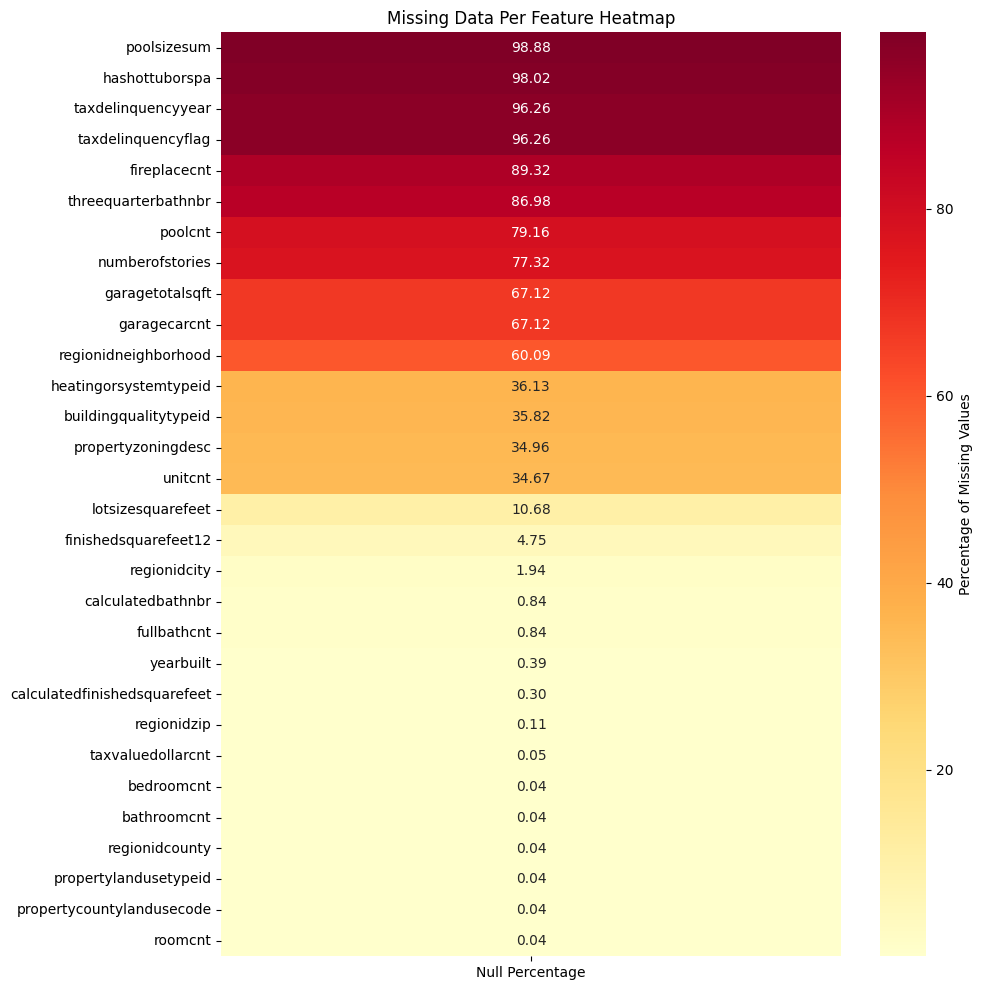

In [34]:
null_pct = null_counts['Null Percentage'].to_frame(name='Null Percentage').sort_values(by='Null Percentage', ascending=False)

plt.figure(figsize=(10, 12))
sns.heatmap(null_pct, annot=True, fmt=".2f", cmap='YlOrRd', cbar_kws={'label': 'Percentage of Missing Values'})
plt.title('Missing Data Per Feature Heatmap')
plt.show()

#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped

Many of the features removed with high null counts had to do with removing features that are simply noise and multicollinearity issues. For example, the *finishedsquarefeet* features (`finishedsquarefeet13`, `finishedsquarefeet6`, `finishedsquarefeet15`, `finishedsquarefeet50`, `finishedfloor1squarefeet`) were redundant since they capture partial information from the aggregated feature, `calculatedfinishedsquarefeet`. Including these features would lead to multicollinearity and result in a poorer model. `storytypeid` was removed because of its high percentage (99.94%) of missing data which the model would not have enough information to properly learn from. The same goes for `buildingclasstypeid`. `yardbuildingsqft26` and `yardbuildingsqft17` were also dropped due to their high percentage of missing data which would just be noise rather than helping the model. While `architecturalstyletypeid` could be an influential feature for the overall price of a house, but since there is essentially no data in this column it would not be very helpful to the model. The same goes for `typeconstructiontypeid`. An important thing to note is that not all of the features with high missing data were dropped. This is because of the potental for imputing the features later on in order to make them useful. For example, not all houses have pools but they could be influential in the overall price for those with pools. Another example is the `taxdeliquencyflag` because while most houses were not deliquent, this could be a good feature to keep to see how it might decrease the value of the house for those who are behind on paying their taxes. Features like `decktypeid` and `basementsqft` were removed because most houses did not have data for them.



### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [35]:
row_null_pct = df_clean.isnull().mean(axis=1)
pct_cutoff = 0.55
len_before_drop = len(df_clean)

too_many_nulls = row_null_pct[row_null_pct >= pct_cutoff]
print(f"Number of rows with over {(pct_cutoff * 100):.0f}% missing data: {len(too_many_nulls)} out of {len_before_drop}")
print(f"Percentage of rows with over {(pct_cutoff * 100):.0f}% missing data: {((len(too_many_nulls) / len_before_drop) * 100):.2f}%")

Number of rows with over 55% missing data: 281 out of 77613
Percentage of rows with over 55% missing data: 0.36%


In [36]:
df_clean = df_clean[row_null_pct <= pct_cutoff]
print(f"Dropped {len_before_drop - len(df_clean)} rows")

Dropped 281 rows


In [37]:
print(f"Missing targets: {df_clean['taxvaluedollarcnt'].isnull().sum()}")
df_clean[df_clean['taxvaluedollarcnt'].isnull()]

Missing targets: 1


,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,lotsizesquarefeet,poolcnt,poolsizesum,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,threequarterbathnbr,unitcnt,yearbuilt,numberofstories,taxdelinquencyflag,taxdelinquencyyear,taxvaluedollarcnt
62558,2.0,4.0,NaN,2.0,1197.0,1197.0,NaN,2.0,1.0,264.0,NaN,NaN,7210.0,1.0,NaN,122,261.0,NaN,24832.0,1286.0,NaN,97048.0,7.0,NaN,NaN,1954.0,1.0,NaN,NaN,NaN


In [38]:
len_before_drop = len(df_clean)
df_clean = df_clean.dropna(subset=['taxvaluedollarcnt'])
print(f"Dropped {len_before_drop - len(df_clean)} rows")

Dropped 1 rows


In [39]:
lower_bound = df_clean['taxvaluedollarcnt'].quantile(0.005)
upper_bound = df_clean['taxvaluedollarcnt'].quantile(0.995)

# Outliers
outliers_removed = df_clean[(df_clean['taxvaluedollarcnt'] >= lower_bound) & (df_clean['taxvaluedollarcnt'] <= upper_bound)]

dropped_count = len(df_clean) - len(outliers_removed)
dropped_pct = (dropped_count / len(df_clean)) * 100

print(f"Dropped {dropped_count} rows")
print(f"{dropped_pct:.2f}% rows dropped")

Dropped 774 rows
1.00% rows dropped


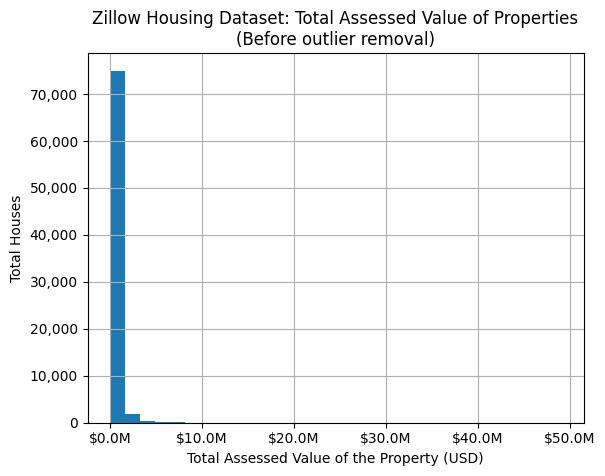

In [40]:
def millions_formatter(x, pos):
    return f'${x*1e-6:1.1f}M'

def frequency_formatter(x, pos):
    return f'{x:,.0f}'

x_formatter = FuncFormatter(millions_formatter)
y_formatter = FuncFormatter(frequency_formatter)

ax = df_clean['taxvaluedollarcnt'].hist(bins=30)
ax.xaxis.set_major_formatter(x_formatter)
ax.yaxis.set_major_formatter(y_formatter)

plt.title('Zillow Housing Dataset: Total Assessed Value of Properties\n(Before outlier removal)')
plt.ylabel('Total Houses')
plt.xlabel('Total Assessed Value of the Property (USD)')
plt.show()

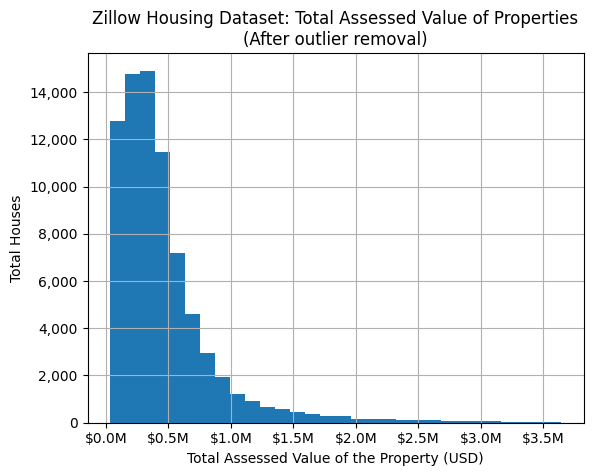

In [41]:
ax = outliers_removed['taxvaluedollarcnt'].hist(bins=30)
ax.xaxis.set_major_formatter(x_formatter)
ax.yaxis.set_major_formatter(y_formatter)

plt.title('Zillow Housing Dataset: Total Assessed Value of Properties\n(After outlier removal)')
plt.ylabel('Total Houses')
plt.xlabel('Total Assessed Value of the Property (USD)')
plt.show()

#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped

Originally set `pct_cutoff` to 0.5, but that was roughly 4% of the data (3188 rows). `pct_cutoff` set to 0.55 is more conservative as it flags just 0.69% of the data (538 rows). Dropping rows should be more conservative since we will be imputing the data later on. There was only one sample with a missing target, so it was safe to drop since there is still plenty of usable samples (> 7000). Removing the bottom and top 0.05% removes the major outliers while leaving 99% of the remaining data. Especially on the upper bound of the histogram showing before the removal, you could see that the scaling shows an outlier in the $50M range while everything else is scrunched to the left side. After cleaning the data, you can see a more typical histogram for real estate where the majority of houses are < $500K and the data is right skewed with a tail of more luxurious/expensive homes.


### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [42]:
df_clean = outliers_removed.copy()

In [43]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76557 entries, 0 to 77612
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bathroomcnt                   76557 non-null  float64
 1   bedroomcnt                    76557 non-null  float64
 2   buildingqualitytypeid         49237 non-null  float64
 3   calculatedbathnbr             76193 non-null  float64
 4   calculatedfinishedsquarefeet  76549 non-null  float64
 5   finishedsquarefeet12          73181 non-null  float64
 6   fireplacecnt                  8271 non-null   float64
 7   fullbathcnt                   76193 non-null  float64
 8   garagecarcnt                  25403 non-null  float64
 9   garagetotalsqft               25403 non-null  float64
 10  hashottuborspa                1490 non-null   object 
 11  heatingorsystemtypeid         49008 non-null  float64
 12  lotsizesquarefeet             68414 non-null  float64
 13  poolcn

In [44]:
cat_cols = df_clean.select_dtypes(include=['object'])
num_cols = df_clean.select_dtypes(exclude=['object'])

In [45]:
# Houses without pools (na) should be set to 0 so they aren't imputed and giving them pools
df_clean['poolcnt'] = df_clean['poolcnt'].fillna(0)

# First set the missing values as 0 since many houses don't have fireplaces, then impute
df_clean['fireplacecnt'] = df_clean['fireplacecnt'].fillna(0)

In [46]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

estimator = ExtraTreesRegressor(n_jobs=-1, max_depth=10, n_estimators=10, random_state=random_state)

imputer = IterativeImputer(max_iter=10, tol=0.001, random_state=random_state, estimator=estimator, verbose=2)

df_num_imputed = pd.DataFrame(data=imputer.fit_transform(df_clean[num_cols.columns]),
                              columns=num_cols.columns,
                              index=df_clean.index)

df_clean[num_cols.columns] = df_num_imputed

[IterativeImputer] Completing matrix with shape (76557, 26)
[IterativeImputer] Ending imputation round 1/10, elapsed time 5.06
[IterativeImputer] Change: 1892220.209191115, scaled tolerance: 6971.01 
[IterativeImputer] Ending imputation round 2/10, elapsed time 10.28
[IterativeImputer] Change: 1370409.8231218355, scaled tolerance: 6971.01 
[IterativeImputer] Ending imputation round 3/10, elapsed time 16.96
[IterativeImputer] Change: 1327545.894162634, scaled tolerance: 6971.01 
[IterativeImputer] Ending imputation round 4/10, elapsed time 23.69
[IterativeImputer] Change: 956659.5152846783, scaled tolerance: 6971.01 
[IterativeImputer] Ending imputation round 5/10, elapsed time 30.43
[IterativeImputer] Change: 1793420.4069705927, scaled tolerance: 6971.01 
[IterativeImputer] Ending imputation round 6/10, elapsed time 37.12
[IterativeImputer] Change: 1820102.0426091563, scaled tolerance: 6971.01 
[IterativeImputer] Ending imputation round 7/10, elapsed time 43.73
[IterativeImputer] Chang

c:\python311\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Used ExtraTreesRegressor rather than the default BayesianRidge estimator for the imputation because it fits several random decision trees that is faster and less prone to overfitting compared to random forests. Since the housing data is not linear, it made sense to use a tree regressor for better imputations.

https://medium.com/learning-data/iterative-imputer-for-missing-values-in-machine-learning-32bd8b5b697a

In [47]:
# Check imputed data to make sure the values make sense

nan_count = df_clean[num_cols.columns].isnull().sum().sum()
print(f"Total NaNs remaining in numerical columns: {nan_count}")

for i in num_cols.columns:
    print(f"{i}: {df_clean[i].unique().tolist()}\n")

Total NaNs remaining in numerical columns: 0
bathroomcnt: [3.5, 1.0, 2.0, 3.0, 2.5, 4.5, 4.0, 5.0, 6.5, 0.0, 1.5, 6.0, 5.5, 7.0, 9.0, 8.0, 10.0, 7.5, 8.5]

bedroomcnt: [4.0, 2.0, 3.0, 6.0, 5.0, 1.0, 0.0, 7.0, 8.0, 12.0, 10.0, 9.0, 11.0, 16.0, 13.0]

buildingqualitytypeid: [8.5, 3.851795419567627, 5.984486402807402, 8.0, 7.995022624434389, 9.0, 5.0, 4.181401558864028, 3.7222769383989984, 5.85791816653588, 4.0, 3.868681696144165, 6.0, 7.996538936959209, 5.698887450690336, 7.991561561393598, 10.957093201366796, 7.0, 3.670066350239857, 4.168681696144165, 3.4035652606395543, 10.0, 10.758661157024793, 5.339488188976378, 10.6736010563643, 3.370066350239857, 5.819396955250694, 5.119488188976378, 5.998604049866225, 9.9, 11.01687781805777, 4.3900189985744085, 3.0, 4.291838570088145, 5.898681629385233, 7.8965389369592085, 7.948355957767722, 7.8915615613935985, 7.7333333333333325, 8.1, 8.053333333333333, 9.805263157894737, 5.839488188976378, 8.09672131147541, 5.856414694500567, 5.896346846318232, 

In [48]:
# Round feature values so they are in the context of original features' value units

# buildingqualitytypeid -> nearest whole number
df_clean['buildingqualitytypeid'] = df_clean['buildingqualitytypeid'].round(0).astype(int)

# calculatedbathnbr -> tenths place
df_clean['calculatedbathnbr'] = df_clean['calculatedbathnbr'].round(1)

# calculatedbathnbr -> nearest whole number
df_clean['calculatedfinishedsquarefeet'] = df_clean['calculatedfinishedsquarefeet'].round(0).astype(int)

# finishedsquarefeet12 -> nearest whole number
df_clean['finishedsquarefeet12'] = df_clean['finishedsquarefeet12'].round(0).astype(int)

# fireplacecnt -> nearest whole number
df_clean['fireplacecnt'] = df_clean['fireplacecnt'].round(0).astype(int)

# garagecarcnt -> nearest whole number
df_clean['garagecarcnt'] = df_clean['garagecarcnt'].round(0).astype(int)

# garagetotalsqft -> nearest whole number
df_clean['garagetotalsqft'] = df_clean['garagetotalsqft'].round(0).astype(int)

# heatingorsystemtypeid -> nearest whole number
df_clean['heatingorsystemtypeid'] = df_clean['heatingorsystemtypeid'].round(0).astype(int)

# lotsizesquarefeet -> nearest whole number
df_clean['lotsizesquarefeet'] = df_clean['lotsizesquarefeet'].round(0).astype(int)

# poolsizesum -> nearest whole number
df_clean['poolsizesum'] = df_clean['poolsizesum'].round(0).astype(int)

# propertylandusetypeid -> nearest whole number
df_clean['propertylandusetypeid'] = df_clean['propertylandusetypeid'].round(0).astype(int)

# propertylandusetypeid -> nearest whole number
df_clean['regionidcity'] = df_clean['regionidcity'].round(0).astype(int)

# regionidcounty -> nearest whole number
df_clean['regionidcounty'] = df_clean['regionidcounty'].round(0).astype(int)

# regionidneighborhood -> nearest whole number
df_clean['regionidneighborhood'] = df_clean['regionidneighborhood'].round(0).astype(int)

# regionidzip -> nearest whole number
df_clean['regionidzip'] = df_clean['regionidzip'].round(0).astype(int)

# roomcnt -> nearest whole number
df_clean['roomcnt'] = df_clean['roomcnt'].round(0).astype(int)

# yearbuilt -> nearest whole number
df_clean['yearbuilt'] = df_clean['yearbuilt'].round(0).astype(int)

# numberofstories -> nearest whole number
df_clean['numberofstories'] = df_clean['numberofstories'].round(0).astype(int)

# taxdelinquencyyear -> nearest whole number
df_clean['taxdelinquencyyear'] = df_clean['taxdelinquencyyear'].round(0).astype(int)

In [49]:
print("Original Fireplace Counts:")
print(df['fireplacecnt'].value_counts(dropna=False))

print("\nOriginal Fireplace Flags:")
print(df['fireplaceflag'].value_counts(dropna=False))

df_clean['fireplacecnt'] = df_clean['fireplacecnt'].round(0).astype(int)

# 4. Final Sanity Check: Ensure we have more than just 0s
print("\n\nNew Imputed Fireplace Counts:")
print(df_clean['fireplacecnt'].value_counts())

Original Fireplace Counts:
fireplacecnt
NaN    69324
1.0     7018
2.0      998
3.0      235
4.0       35
5.0        3
Name: count, dtype: int64

Original Fireplace Flags:
fireplaceflag
NaN     77441
True      172
Name: count, dtype: int64


New Imputed Fireplace Counts:
fireplacecnt
0    68286
1     7011
2      995
3      230
4       33
5        2
Name: count, dtype: int64


In [50]:
df['heatingorsystemtypeid'].unique()

array([nan,  2.,  7.,  6., 24., 13., 18., 20.,  1., 10., 11.])

In [51]:
df_clean['heatingorsystemtypeid'].unique()

array([ 6, 15,  2, 16,  7,  8,  9, 21, 13, 14, 17, 18, 19, 22, 10, 11, 12,
        3,  4,  1, 24, 23, 20,  5])

In [52]:
df['buildingqualitytypeid'].unique()

array([nan,  8.,  9.,  5.,  4.,  6.,  7., 10.,  3., 11., 12.,  1.,  2.])

In [53]:
df_clean['buildingqualitytypeid'].unique()

array([ 8,  4,  6,  9,  5, 11,  7,  3, 10, 12,  1,  2])

In [54]:
df['fireplacecnt'].unique()

array([nan,  1.,  2.,  3.,  4.,  5.])

In [55]:
df_clean['fireplacecnt'].unique()

array([0, 1, 2, 3, 4, 5])

In [56]:
# Check imputations and rounded values to ensure data is within the original min/max value ranges (reduce shifting the overall trends on the far ends of the data)

# already fixed poolcnt by replacing NA with 0 manually, so we can skip it.
num_cols = [i for i in num_cols if i != 'poolcnt']

for col in num_cols:
    if col in df_clean.columns and col in df.columns:
        original_min = 0 if col == 'fireplacecnt' else df[col].min()        # override fireplacecnt min to be 0 since original is technically 1 but houses with nan for fireplaceflag should have 0
        original_max = df[col].max()

        # check how many values are outside of the original bounds
        under_count = (df_clean[col] < original_min).sum()
        over_count = (df_clean[col] > original_max).sum()

        if under_count > 0 or over_count > 0:
            print(f"Checking {col:.<30} Under: {under_count} | Over: {over_count}")

            # Clip the values to the original min and max range
            df_clean[col] = df_clean[col].clip(lower=original_min, upper=original_max)

In [57]:
# Cross-check values to ensure the flag is consistent with the fireplacecnt (can't have 0 fireplacecnt if flag is True)

# align indexes since df_clean has dropped samples
aligned_flag = df['fireplaceflag'].reindex(df_clean.index)

flag_true = (aligned_flag == True)
count_zero = (df_clean['fireplacecnt'] == 0).values

mismatch_mask = flag_true & count_zero
mismatch_count = mismatch_mask.sum()

print(f"Mismatches (Flag=True but Count=0): {mismatch_count}")

# give the mismatched samples 1 fireplacecnt to make the logic between two features consistent
if mismatch_count > 0:
    df_clean.loc[mismatch_mask, 'fireplacecnt'] = 1
    print(f"Fixed {mismatch_count} rows.")

Mismatches (Flag=True but Count=0): 172
Fixed 172 rows.


In [58]:
# Check imputations and rounded values for the identifier features to ensure it didn't create a new identifier outside of the original data

id_cols = ['buildingqualitytypeid', 'heatingorsystemtypeid', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip']

for col in id_cols:

    # Original data values
    valid_id = np.sort(df[col].dropna().unique())

    # Imputed data values
    current_vals = df_clean[col].unique()

    # Check for invalid IDs (not one of the original values)
    invalid_vals = [i for i in current_vals if i not in valid_id]

    if invalid_vals:
        print(f"Fixing {col:.<30} Found {len(invalid_vals)} invented IDs.")

        # finds the closest valid_id to the invalid_vals
        mapped = {invalid: valid_id[np.abs(valid_id - invalid).argmin()] for invalid in invalid_vals}

        # replace invalid_vals with the closest valid_id
        df_clean[col] = df_clean[col].replace(mapped)


Fixing heatingorsystemtypeid......... Found 14 invented IDs.
Fixing regionidcity.................. Found 954 invented IDs.
Fixing regionidneighborhood.......... Found 18717 invented IDs.
Fixing regionidzip................... Found 27 invented IDs.


In [59]:
# check that roomcnt is at least the bedroomcnt + bathroomcnt (since no features include living room, kitchen, other rooms)

# temporary feature to check for inconsistent totals (0 roomcnt but there are bedrooms and bathrooms)
df_clean['min_rooms_count'] = df_clean['bedroomcnt'] + df_clean['bathroomcnt']

# if room count (house's total room count) is less than minimum rooms count, set to the minimum
mask = df_clean['roomcnt'] < df_clean['min_rooms_count']
df_clean.loc[mask, 'roomcnt'] = df_clean.loc[mask, 'min_rooms_count']

# drop temporary min_rooms_count feature
df_clean.drop(columns=['min_rooms_count'], inplace=True)

df_clean['roomcnt'] = df_clean['roomcnt'].astype(float)

df_clean['roomcnt'].unique()

C:\Users\Aidan\AppData\Local\Temp\ipykernel_7480\545061114.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[7.5 7.  6.  ... 4.  4.  5. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_clean.loc[mask, 'roomcnt'] = df_clean.loc[mask, 'min_rooms_count']


array([ 7.5,  5. ,  6. ,  7. ,  3. ,  5.5,  4. ,  8. , 11. ,  6.5,  9. ,
        2. ,  4.5, 10. ,  1. , 11.5,  0. ,  9.5, 12. ,  3.5,  2.5, 10.5,
       15. , 17. , 13. ,  8.5, 20. , 14. , 12.5, 16. , 18. , 19. , 13.5,
       14.5, 24. , 23. ])

In [60]:
df_clean[df_clean['roomcnt'] == 0]

,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,lotsizesquarefeet,poolcnt,poolsizesum,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,threequarterbathnbr,unitcnt,yearbuilt,numberofstories,taxdelinquencyflag,taxdelinquencyyear,taxvaluedollarcnt
96,0.0,0.0,8,1.2,4198,4256,0,1.1,1,0,NaN,20,6187,0.0,444,96,248,NaN,47568,1286,268509,97007,0.0,1.0,4.000000,1977,2,NaN,15,480448.0
209,0.0,0.0,8,1.3,5041,4662,0,1.0,0,0,NaN,2,7832,0.0,720,96,248,NaN,25218,1286,623346,96965,0.0,1.0,4.000000,1979,2,NaN,12,1196253.0
273,0.0,0.0,8,1.0,1482,1486,0,1.0,0,0,NaN,1,4751,0.0,731,38,246,NaN,13693,1286,260611,96982,0.0,1.0,1.000000,1974,2,NaN,11,372535.0
445,0.0,0.0,3,1.0,2220,2220,0,1.0,1,193,NaN,18,7979,0.0,459,1321,247,NaN,13150,2061,762527,97104,0.0,1.1,3.000000,1949,1,NaN,10,357140.0
988,0.0,0.0,3,1.0,1101,1114,0,1.0,1,121,NaN,7,2512,0.0,505,1720,31,LAC2,12447,3101,118208,96025,0.0,1.0,1.000000,1919,1,NaN,15,137933.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76506,0.0,0.0,8,1.0,3608,3583,0,1.0,0,0,NaN,6,7769,0.0,598,96,248,NaN,33252,1286,417433,97063,0.0,1.0,4.000000,1979,2,NaN,12,952710.0
76578,0.0,0.0,4,1.0,2122,2071,1,1.0,1,45,NaN,7,16331,0.0,531,1222,246,NaN,26965,2061,761547,97113,0.0,1.1,2.000000,1961,1,NaN,10,400000.0
76579,0.0,0.0,6,1.0,2390,2413,0,1.0,2,238,NaN,7,5860,0.0,493,0200,246,LBR1N,46298,3101,276476,96239,0.0,1.0,2.000000,1972,1,NaN,15,137309.0
77175,0.0,0.0,6,1.0,2307,2307,0,1.0,2,457,NaN,2,11880,0.0,991,0100,261,DOC4*,4406,3101,156012,96100,0.0,1.0,1.000000,1948,1,Y,15,499000.0


In [61]:
# Data still has issues with the logic of the roomcnt feature (houses with 0 rooms, but have values for at least calculatedbathnbr)
# target the 337 rows so that they have a logical roomcnt total

zero_room_mask = (df_clean['roomcnt'] == 0)

# the house should at least have the bathrooms and 1 living/bedroom space - rounded so that each room is counted as 1 like original data
df_clean.loc[zero_room_mask, 'roomcnt'] = (df_clean.loc[zero_room_mask, 'calculatedbathnbr'] + 1).round(0).astype(int)

In [62]:
# improve readability for the taxdelinquencyyear

# making sure a year doesn't get added to taxdelinquencyyear if the flag is NaN
has_flag = df_clean['taxdelinquencyflag'].notna()

mask_99 = has_flag & (df_clean['taxdelinquencyyear'] == 99)
mask_under_99 = has_flag & (df_clean['taxdelinquencyyear'] < 99)

# Add 1900 to '99' to get 1999
df_clean.loc[mask_99, 'taxdelinquencyyear'] += 1900

# Add 2000 to values like '06', '12', etc. to get 2006, 2012
df_clean.loc[mask_under_99, 'taxdelinquencyyear'] += 2000

# if flag is NaN, set the year to NaN
df_clean.loc[~has_flag, 'taxdelinquencyyear'] = np.nan

In [98]:
df_clean[df_clean['taxdelinquencyyear'].notna()]

,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,lotsizesquarefeet,poolcnt,poolsizesum,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,threequarterbathnbr,unitcnt,yearbuilt,numberofstories,taxdelinquencyflag,taxdelinquencyyear,taxvaluedollarcnt
19,2.0,2.0,4,2.0,916,916,0,2.0,1,0,0,20,3717,0.0,449,34,266,UNKNOWN,37086,1286,276606,96962,4.0,1.0,2.109671,1980,1,1,2015.0,245910.0
20,2.0,3.0,6,2.0,1092,1092,0,2.0,2,46,0,2,36005,0.0,991,010C,266,PARM*,6395,3101,118920,96220,5.0,1.0,1.000000,1979,1,1,2015.0,178646.0
23,1.0,2.0,5,1.0,1316,1316,0,1.0,2,405,0,7,5091,0.0,500,0100,261,LAC2,12447,3101,268496,96018,3.0,1.0,1.000000,1908,1,1,2014.0,171838.0
54,1.0,2.0,5,1.0,609,609,0,1.0,2,453,0,7,8997,0.0,503,0100,261,LCA105,37015,3101,417433,96464,3.0,1.0,1.000000,1948,1,1,2015.0,162320.0
72,1.0,2.0,4,1.0,776,776,0,1.0,1,309,0,7,7055,0.0,498,0100,261,LAR1,12447,3101,40215,96361,3.0,1.0,1.000000,1946,1,1,2015.0,164836.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77492,2.0,2.0,6,2.0,925,925,0,2.0,3,0,0,2,842267,0.0,944,010C,266,SCUR3,54311,3101,48200,96378,4.0,1.0,1.000000,1989,1,1,2015.0,142958.0
77519,3.0,3.0,8,3.0,1401,1401,0,3.0,2,0,0,2,73554,1.0,959,010C,266,LAR3,12447,3101,32368,96415,6.0,1.2,1.000000,1981,2,1,2015.0,350260.0
77566,3.0,4.0,4,3.0,2054,2109,0,3.0,0,69,0,7,6284,0.0,501,0300,247,LARD2,12447,3101,757352,95999,7.0,1.3,3.000000,1905,1,1,2015.0,477167.0
77586,1.0,2.0,4,1.0,832,832,0,1.0,2,277,0,7,3743,0.0,544,0100,261,HGR2*,21778,3101,343505,96216,3.0,1.0,1.000000,1956,1,1,2012.0,143238.0


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset

For the numeric columns, we captured the relationships of the features in order to get a better imputation result rather than the simple median/mean. This is because with housing datasets there are complex relationships with several factors that could affect the overall price. Taking a mean, median, or mode may skew the data for houses. For example, a mean would affect lower house prices more as the numeric features may be skewed from outlier or higher value samples. A median is better than a mean because it is less sensitive to outliers, but it still fails to capture the *why* behind the missing value. In this dataset, the features are tied to specific characteristics of a property that all potentially affect the overall evaluation of the house. Using a simple median treats a small house and a mansion the same way if they both happen to be missing a value for the number of bathrooms for example. Capturing the relationships between features will give us a more contextual imputation that preserves the overall relationships between features for each sample. In terms of the hyperparameters for the estimator, we kept the n_estimators and the max_depth low to prevent overfitting. Other features required manual overrides in order to make sure they logically make sense (eg. roomcnt).


### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [64]:
cat_cols.head()

,hashottuborspa,propertycountylandusecode,propertyzoningdesc,taxdelinquencyflag
0,NaN,122,NaN,NaN
1,NaN,1110,NaN,NaN
2,NaN,122,NaN,NaN
3,NaN,0101,LCR110000*,NaN
4,NaN,010C,LAR3,NaN


In [65]:
df_clean['hashottuborspa'].unique()

array([nan, True], dtype=object)

In [66]:
df_clean['hashottuborspa'] = df_clean['hashottuborspa'].fillna(False).infer_objects(copy=False)

C:\Users\Aidan\AppData\Local\Temp\ipykernel_7480\3867410208.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['hashottuborspa'] = df_clean['hashottuborspa'].fillna(False).infer_objects(copy=False)


In [67]:
df_clean['hashottuborspa'].unique()

array([False,  True])

In [68]:
# Encodes feature into binary 0, 1 rather than False, True
df_clean['hashottuborspa'] = df_clean['hashottuborspa'].astype(int)

In [69]:
df_clean['hashottuborspa'].unique()

array([0, 1])

In [70]:
df_clean['taxdelinquencyflag'].unique()

array([nan, 'Y'], dtype=object)

In [71]:
# Convert and encode feature into binary
df_clean['taxdelinquencyflag'] = df_clean['taxdelinquencyflag'].map({'Y': 1}).fillna(0).astype(int)
df_clean['taxdelinquencyflag'].unique()

array([0, 1])

In [72]:
df_clean[cat_cols.columns].head()

,hashottuborspa,propertycountylandusecode,propertyzoningdesc,taxdelinquencyflag
0,0,122,NaN,0
1,0,1110,NaN,0
2,0,122,NaN,0
3,0,0101,LCR110000*,0
4,0,010C,LAR3,0


In [73]:
df_clean['propertyzoningdesc'].unique().tolist()

[nan,
 'LCR110000*',
 'LAR3',
 'PSR2',
 'GLR4YY',
 'WHRE20000*',
 'SCUR2',
 'GLR3*',
 'LCR2YY',
 'PARM*',
 'LAC2',
 'LARD3',
 'LBR1S',
 'LARD1.5',
 'RPRS10000*',
 'LCA11*',
 'LFR120000*',
 'LARE9',
 'LAR1',
 'PSR*',
 'PSR3',
 'INP1YY',
 'GDRHR',
 'GDR_GA_PD',
 'LARE11',
 'LCA105',
 'LAR2',
 'TCR1*',
 'LBR1L',
 'LCR3*',
 'LCA11L',
 'WARPD14800',
 'LARS',
 'LACW',
 'POR17200*',
 'POR31000*',
 'WAC3*',
 'LVRSP87-19',
 'LKR1YY',
 'HHRAS1*',
 'SCUR3',
 'CARS*',
 'LARD2',
 'BUR1YY',
 'BHR4*',
 'LBR2N',
 'LARE15',
 'LCR315U*',
 'SPR310000*',
 'BFR1YY',
 'LRR7000*',
 'DOR106',
 'LCRPD60005',
 'LCA1*',
 'LAC5',
 'MNR1YY',
 'PSR4',
 'CEADP3',
 'LARA',
 'GDE4',
 'CERS5000',
 'PSR6',
 'WARPD16800',
 'SCSP',
 'POPRD*',
 'INR1YY',
 'LVPR2D*',
 'ALRPD*',
 'PRSF*',
 'PDR17500*',
 'PDR1*',
 'LYR3YY',
 'LCA25*',
 'BGR3*',
 'SCCP',
 'LCR175',
 'SLR1YY',
 'PDRI 7000',
 'LCA110000*',
 'CORL*',
 'COR1*',
 'ARROD*',
 'ARR0*',
 'ARRO*',
 'PDSP*',
 'LRMD2',
 'DOR105',
 'PDRPD-3U*',
 'LCA21*',
 'ARR1YY',
 'BGA1

We will engineer the zoning description feature, `propertyzoningdesc` because it might be valueable to consider since it affects what might be around the house. First, we need to fill the NA values with UNKNOWN prior to feature engineering.

In [74]:
df_clean['propertyzoningdesc'] = df_clean['propertyzoningdesc'].fillna("UNKNOWN")

In [75]:
null_counts = df_clean.isnull().sum().to_frame(name='Null Counts')
null_counts['Non-Null Counts'] = df_clean.notnull().sum()
null_counts['Null Percentage'] = (null_counts['Null Counts'] / len(df_clean)) * 100

null_counts.sort_values(by='Null Percentage', ascending=False)

,Null Counts,Non-Null Counts,Null Percentage
taxdelinquencyyear,73738,2819,96.317776
bathroomcnt,0,76557,0.000000
buildingqualitytypeid,0,76557,0.000000
calculatedbathnbr,0,76557,0.000000
calculatedfinishedsquarefeet,0,76557,0.000000
bedroomcnt,0,76557,0.000000
fireplacecnt,0,76557,0.000000
fullbathcnt,0,76557,0.000000
garagecarcnt,0,76557,0.000000
garagetotalsqft,0,76557,0.000000


In [76]:
df_imputed = df_clean.copy()
df_imputed.head()

,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,lotsizesquarefeet,poolcnt,poolsizesum,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,threequarterbathnbr,unitcnt,yearbuilt,numberofstories,taxdelinquencyflag,taxdelinquencyyear,taxvaluedollarcnt
0,3.5,4.0,8,3.5,3100,3100,0,3.0,2,633,0,6,4506,0.0,618,122,261,UNKNOWN,53571,1286,191484,96978,7.5,1.0,1.684627,1998,2,0,NaN,1023282.0
1,1.0,2.0,4,1.0,1465,1465,1,1.0,1,0,0,13,12647,0.0,454,1110,261,UNKNOWN,13091,2061,761000,97099,5.0,1.0,2.502556,1967,1,0,NaN,464000.0
2,2.0,3.0,6,2.0,1243,1243,0,2.0,2,440,0,6,8432,1.0,606,122,261,UNKNOWN,21412,1286,403127,97078,6.0,1.0,1.400057,1962,1,0,NaN,564778.0
3,3.0,4.0,8,3.0,2376,2376,0,3.0,2,532,0,2,13038,1.0,860,0101,261,LCR110000*,396551,3101,403127,96330,7.0,1.3,1.000000,1970,2,0,NaN,145143.0
4,3.0,3.0,8,3.0,1312,1312,0,3.0,2,0,0,2,278581,1.0,959,010C,266,LAR3,12447,3101,268548,96451,6.0,1.2,1.000000,1964,2,0,NaN,119407.0


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

